<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/entregable_tarea_5_1_alfaro_cruz_p_rez_rupit_medea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contaminación Atmosférica y Calidad del Aire (PM2.5)

## Exploración y Preprocesamiento
15% Manejo adecuado de valores nulos, codificación de categóricas y escalamiento de variables (crítico para GLM, L1/$L_2$ y Redes Neuronales).

## Resumen de la programación realizada en este código

1) ashdgjasgdjha
2) ajsdajhds


In [1]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas

In [2]:
# Importar la información
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

In [3]:
# Mostrar las primeras 5 filas
df.sample(10)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
33600,33601,2013,11,1,0,274.0,2,5.0,1028.0,SE,0.89,0,0
36761,36762,2014,3,12,17,13.0,-25,10.0,1023.0,cv,0.89,0,0
28452,28453,2013,3,31,12,230.0,3,7.0,1020.0,SE,81.38,0,0
12748,12749,2011,6,16,4,96.0,17,20.0,1006.0,cv,0.89,0,0
2130,2131,2010,3,30,18,NaN,7,9.0,1014.0,NE,1.78,0,8
40686,40687,2014,8,23,6,120.0,21,22.0,1006.0,NE,0.89,0,0
40797,40798,2014,8,27,21,82.0,17,24.0,1013.0,SE,1.79,0,0
10922,10923,2011,4,1,2,147.0,-3,15.0,1018.0,NE,21.01,0,0
6390,6391,2010,9,24,6,NaN,10,12.0,1018.0,cv,2.67,0,0
22373,22374,2012,7,21,5,174.0,25,26.0,1003.0,SE,46.07,0,0


# Glosario de Columnas Relevantes

pm2.5 --> PM25: Concentración de partículas PM2.5 (material particulado fino)

DEWP: Punto de rocío (Dew Point)

TEMP: Temperatura ambiente

PRES: Presión atmosférica

cbwd --> WIND_DIRECTION : Dirección combinada del viento

lws --> WIND_SPEED: velocidad acumulada del viento

ls: Horas acumuladas de nieve

lr: Horas acumuladas de lluvia

 -NW: Viento del noroeste

 -NE: Viento del noreste

 -SE: Viento del sureste

 -cv: Calm Variable (viento muy debil o dirección variable). *Combinación de las tres anteriores, sin rumbo fijo.

In [4]:
# Revisar el tipos de datos y columnas presentes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  str    
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


In [5]:
#Renombrar encabezados
df = df.rename(columns={"No": "NO",
                        "year": "YEAR",
                        "month": "MONTH",
                        "day": "DAY",
                        "hour": "HOUR",
                        "pm2.5": "PM25",
                        "DEWP": "DEWPOINT",
                        "TEMP": "TEMP",
                        "PRES": "PRESION",
                        "cbwd": "WIND_DIRECTION",
                        "Iws": "WIND_SPEED",
                        "Is": "SNOW",
                        "Ir": "RAIN"})
df.info()  # Revisar el tipos de datos y columnas presentes

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NO              43824 non-null  int64  
 1   YEAR            43824 non-null  int64  
 2   MONTH           43824 non-null  int64  
 3   DAY             43824 non-null  int64  
 4   HOUR            43824 non-null  int64  
 5   PM25            41757 non-null  float64
 6   DEWPOINT        43824 non-null  int64  
 7   TEMP            43824 non-null  float64
 8   PRESION         43824 non-null  float64
 9   WIND_DIRECTION  43824 non-null  str    
 10  WIND_SPEED      43824 non-null  float64
 11  SNOW            43824 non-null  int64  
 12  RAIN            43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


In [6]:
# Crear una columna con la fecha a partir de year, month, day y hour
# Mostrar resultados
df['FECHA'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY', 'HOUR']]) # Crea una columna con la fecha
print("Rango de fechas del dataset:")
print(f"Desde: {df['FECHA'].min()} hasta {df['FECHA'].max()}")


Rango de fechas del dataset:
Desde: 2010-01-01 00:00:00 hasta 2014-12-31 23:00:00


In [7]:
# Análisis de métricas principales de la información
df.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR"]).describe() # Estadísticas básicas sin considerar las fechas

,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,FECHA
count,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824
mean,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916,2012-07-01 23:30:00
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000,2010-01-01 00:00:00
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000,2011-04-02 11:45:00
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000,2012-07-01 23:30:00
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000,2013-10-01 11:15:00
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000,2014-12-31 23:00:00
std,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867,NaN


Nota: El rango de las variables (diferente entre ellas) puede afectar el modelo por lo que es posible que se deba normalizar

In [8]:
threshold = df['PM25'].quantile(0.99)
filtered_df = df[df['PM25'] >= threshold]
filtered_df['PM25'].describe()

count    423.000000
mean     493.101655
std       87.652354
min      420.000000
25%      439.000000
50%      470.000000
75%      508.000000
max      994.000000
Name: PM25, dtype: float64

En este bloque revisamos los outliers variando el percentil, no eliminamos dato.

In [9]:
# Revisión de datos nulos de la información
df.isnull().sum()

NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25              2067
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_DIRECTION       0
WIND_SPEED           0
SNOW                 0
RAIN                 0
FECHA                0
dtype: int64

In [10]:
# Porcentaje de vacíos en la información por modelar
x = 2067/43824*100
print(round(x, 3), '%')

4.717 %


Sólo la variable por modelar tiene valores nulos y es menos del 4.72%

Text(0.5, 0, 'Concentración μg/m³')

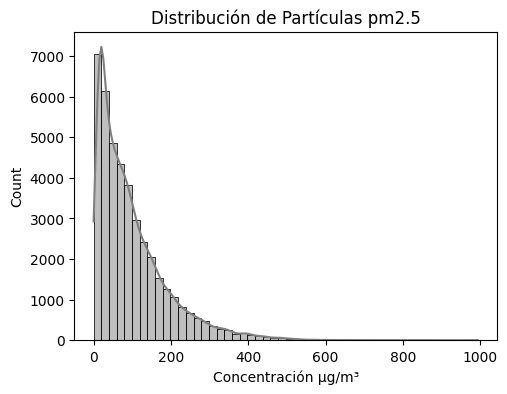

In [11]:
# Configuración de los gráficos
plt.figure(figsize=(12, 4))

# 1. Gráfico para ver la distribución de pm2.5 e identificar sesgos o valores atípicos (outliers)
plt.subplot(1, 2, 1)
sns.histplot(df['PM25'].dropna(), bins=50, kde=True, color='grey')
plt.title('Distribución de Partículas pm2.5')
plt.xlabel('Concentración μg/m³')

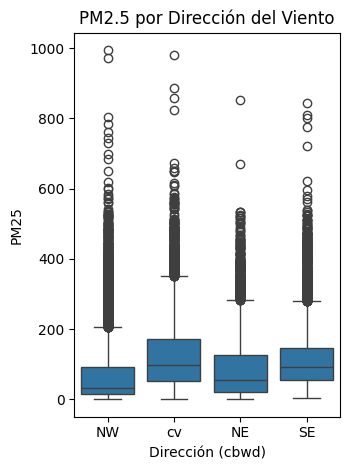

In [12]:
# 2. Gráfico de caja para ver cómo afecta el viento en calma ('cv') frente a los otros a las PM2.5
plt.subplot(1, 2, 2)
sns.boxplot(x='WIND_DIRECTION', y='PM25', data=df)
plt.title('PM2.5 por Dirección del Viento')
plt.xlabel('Dirección (cbwd)')
plt.tight_layout()
plt.show()

In [13]:
# Crear un índice con la fecha
#df_temporal = df.set_index('FECHA') # Hacer un índice con la fecha
# Graficar dos columnas en la misma serie temporal
#plt.figure(figsize=(10,6))
#plt.plot(df_temporal, df["PM25"], label='Concentración', color='orange')
#plt.plot(df_temporal, df['DEWP'], label='Rocío', color='grey')

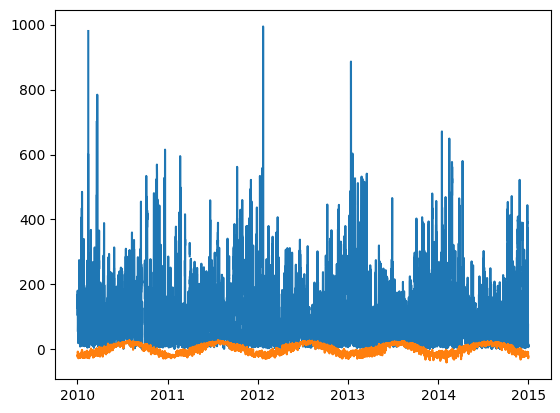

In [14]:
plt.plot(df["FECHA"], df["PM25"], label="pm2.5")
plt.plot(df["FECHA"], df["DEWPOINT"], label="DEWP")

In [15]:
# Rellenar nulos con la mediana
# df['pm2.5'] = df['pm2.5'].fillna(df['pm2.5'].median())

Opción 1: Eliminar nulos

Opción 2: Rellenar con la media

Opción 3: Rellenar con interpolación temporal

================================== Analisis y limpieza ===============================

In [18]:
df.describe()
df.info()
df.sample(10)

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   NO              43824 non-null  int64         
 1   YEAR            43824 non-null  int64         
 2   MONTH           43824 non-null  int64         
 3   DAY             43824 non-null  int64         
 4   HOUR            43824 non-null  int64         
 5   PM25            41757 non-null  float64       
 6   DEWPOINT        43824 non-null  int64         
 7   TEMP            43824 non-null  float64       
 8   PRESION         43824 non-null  float64       
 9   WIND_DIRECTION  43824 non-null  str           
 10  WIND_SPEED      43824 non-null  float64       
 11  SNOW            43824 non-null  int64         
 12  RAIN            43824 non-null  int64         
 13  FECHA           43824 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(8), str(1)
memory usage: 

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,WIND_SPEED,SNOW,RAIN,FECHA
5129,5130,2010,8,2,17,29.0,14,31.0,1005.0,SE,6.26,0,0,2010-08-02 17:00:00
22119,22120,2012,7,10,15,53.0,25,32.0,993.0,SE,10.28,0,0,2012-07-10 15:00:00
22584,22585,2012,7,30,0,NaN,22,25.0,1001.0,NW,1.79,0,0,2012-07-30 00:00:00
30382,30383,2013,6,19,22,56.0,13,31.0,1003.0,SE,1.79,0,0,2013-06-19 22:00:00
3305,3306,2010,5,18,17,29.0,12,18.0,1000.0,SE,3.13,0,0,2010-05-18 17:00:00
26987,26988,2013,1,29,11,493.0,-5,-4.0,1026.0,SE,6.26,2,0,2013-01-29 11:00:00
15307,15308,2011,9,30,19,26.0,1,16.0,1023.0,SE,16.99,0,0,2011-09-30 19:00:00
5577,5578,2010,8,21,9,50.0,20,23.0,1012.0,NW,4.92,0,4,2010-08-21 09:00:00
29151,29152,2013,4,29,15,30.0,-14,29.0,1009.0,NW,42.48,0,0,2013-04-29 15:00:00
27801,27802,2013,3,4,9,16.0,-16,9.0,1026.0,NE,3.13,0,0,2013-03-04 09:00:00


In [19]:
print(df.isna().sum())
print("Los valores de la unica columna tipo string (WIND_DIRECTION) son:")
print(df["WIND_DIRECTION"].value_counts())

# convert 'cv' of WIND_DIRECTION column to NA
df["WIND_DIRECTION"] = df["WIND_DIRECTION"].replace("cv", np.nan)

NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25              2067
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_DIRECTION       0
WIND_SPEED           0
SNOW                 0
RAIN                 0
FECHA                0
dtype: int64
Los valores de la unica columna tipo string (WIND_DIRECTION) son:
WIND_DIRECTION
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64


Dropping Data vs. To imput data vs. just leave NAs to the ML

In [20]:
# Dropping Data. Nueva dataset que elimina las files con NAs solo de la columna de pm2.5.

df_clean = df.dropna(subset="PM25")
df_clean.isna().sum()
len(df_clean)

# Impute data. Nuevo dataset imputado... Primero para decidir que tipo de Imputación realizar
# necesito saber que tan independientes o dependientes son mis variables entre si.
# Para ello necesito visualizar posibles correlaciones o relaciones estadisticas entre ellas.

# Dadas las graficas de abajo quiero diferenciar que variables son dependientes de otras, y ver como esto afecta al tipo de imputacion
# despues, normalizamos

41757

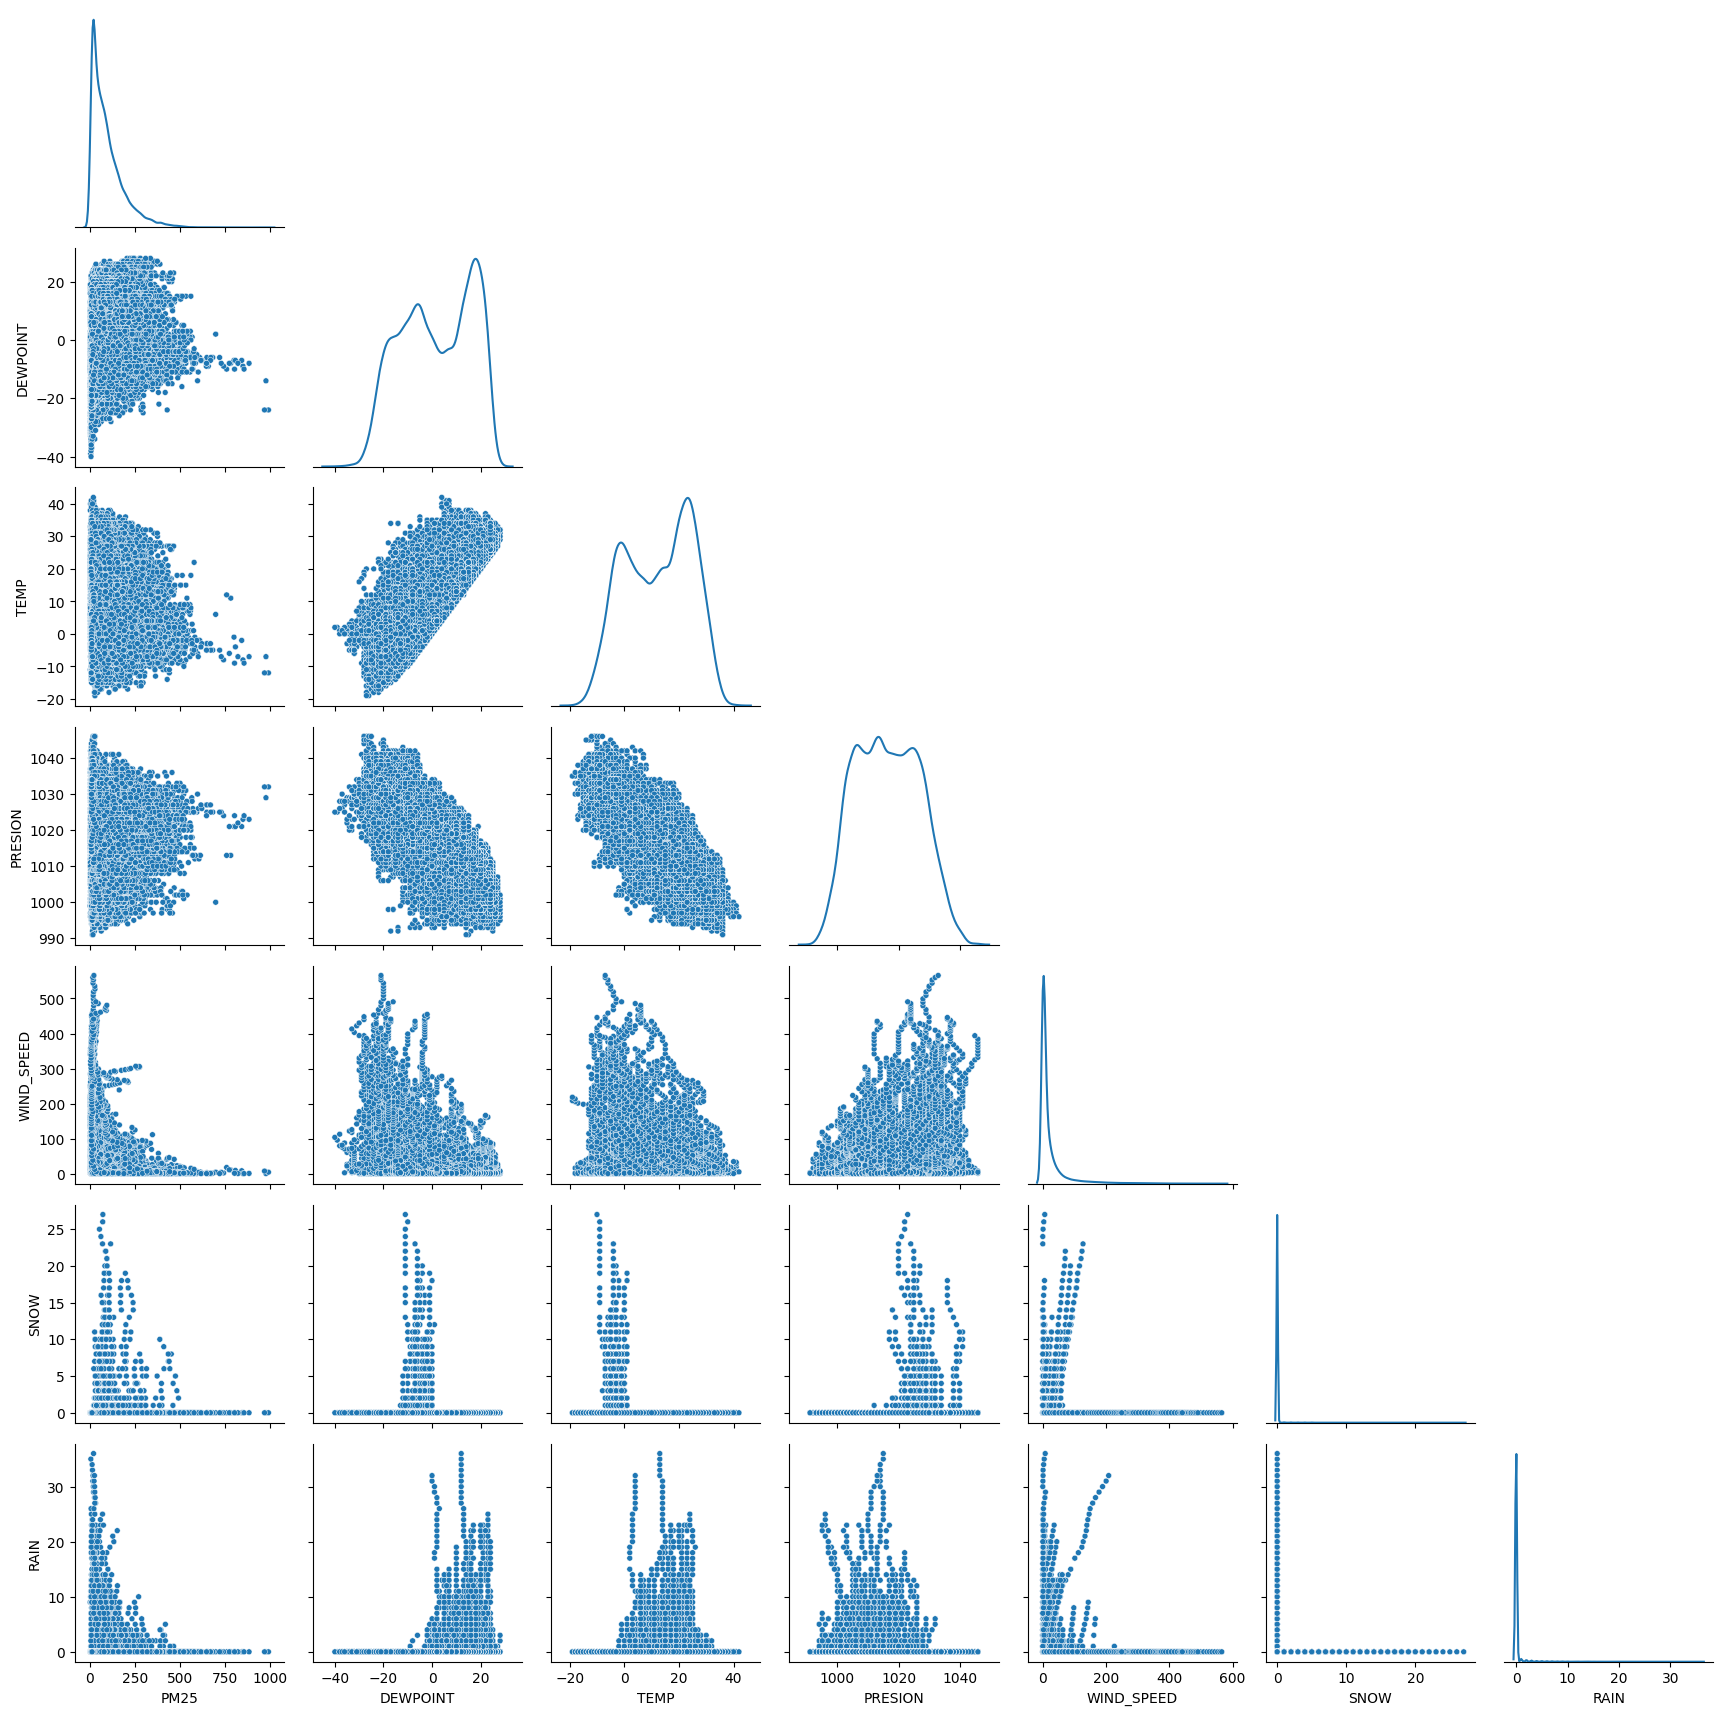

In [22]:
g = sns.PairGrid(df_clean[["PM25", "DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]],
                 diag_sharey=False,
                 corner=True
                )
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot, size=0.1)

In [ ]:
# Time Series only for pm2.5 values

plt.rcParams["figure.dpi"] = 200
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x="FECHA", y="PM25",
             data=df_clean,
             linewidth=0.2,
            )
ax.set(
    ylabel="PM2.5",
    title="Serie de Tiempo de PM2.5",
)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.show


In [ ]:
# La recomendación de las series de tiempo (en un mismo figure)

plt.rcParams["figure.dpi"] = 300

fig, axs = plt.subplots(3,2, figsize=(12,5))
sns.lineplot(x="FECHA", y="DEWPOINT", data=df_clean, linewidth=0.2, ax=axs[0,0])
sns.lineplot(x="FECHA", y="TEMP", data=df_clean, linewidth=0.2, ax=axs[1,0])
sns.lineplot(x="FECHA", y="PRESION", data=df_clean, linewidth=0.2, ax=axs[2,0])
sns.lineplot(x="FECHA", y="WIND_SPEED", data=df_clean, linewidth=0.2, ax=axs[0,1])
sns.lineplot(x="FECHA", y="SNOW", data=df_clean, linewidth=0.2, ax=axs[1,1])
sns.lineplot(x="FECHA", y="RAIN", data=df_clean, linewidth=0.2, ax=axs[2,1])

axs[0]

plt.show